# TP 2 - Classification : Préparation des données

## 1) Importer les librairies

In [282]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
 



## 2) Importer et visualiser le dataset, les colonnes et les valeurs uniques de Purchased

In [283]:
file_path = 'Social_Network_Ads.csv'
dataset = pd.read_csv(file_path)

print('visualisation:')
display(dataset.head())

print('\nColonnes :')
print(dataset.columns.tolist())

print('\nValeurs uniques de Purchased :')
print(dataset['Purchased'].unique())


visualisation:


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0



Colonnes :
['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']

Valeurs uniques de Purchased :
[0 1]


## 3) Nombre de Purchased par Gender (Male/Female)

In [284]:
print(dataset.groupby('Gender')['Purchased'].value_counts())

Gender  Purchased
Female  0            127
        1             77
Male    0            130
        1             66
Name: count, dtype: int64


## 4) Specifier X et y avec iloc

In [285]:
#dataframe.iloc[:, column_index] to retrive colums (iloc[lingne(: means all),colums]) :4 4 doent count
X = dataset.iloc[:, 0:4]
y = dataset.iloc[:, 4]
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64


## 5) Gerer les donnees manquantes et les variables categoriques

In [286]:
print(dataset.isnull().sum()) # no null values


User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [287]:
print(dataset.duplicated().sum()) # no dublicated values

0


In [288]:
dataset["Gender"].unique() #see if there is typos

array(['Male', 'Female'], dtype=object)

In [289]:

# change male female to 0 and 1 
encoder = OneHotEncoder()
transformed_data = encoder.fit_transform(dataset[['Gender']])


dataset[encoder.categories_[0]] = transformed_data.toarray()
dataset.drop('Gender', axis=1, inplace=True)
dataset.head()


,User ID,Age,EstimatedSalary,Purchased,Female,Male
0,15624510,19.0,19000.0,0,0.0,1.0
1,15810944,35.0,20000.0,0,0.0,1.0
2,15668575,26.0,43000.0,0,1.0,0.0
3,15603246,27.0,57000.0,0,1.0,0.0
4,15804002,19.0,76000.0,0,0.0,1.0


In [290]:
# new X
X = dataset[['Female', 'Male', 'Age', 'EstimatedSalary']]
print(X)


     Female  Male   Age  EstimatedSalary
0       0.0   1.0  19.0          19000.0
1       0.0   1.0  35.0          20000.0
2       1.0   0.0  26.0          43000.0
3       1.0   0.0  27.0          57000.0
4       0.0   1.0  19.0          76000.0
..      ...   ...   ...              ...
395     1.0   0.0  46.0          41000.0
396     0.0   1.0  51.0          23000.0
397     1.0   0.0  50.0          20000.0
398     0.0   1.0  36.0          33000.0
399     1.0   0.0  49.0          36000.0

[400 rows x 4 columns]


## 6) Diviser le dataset entre le Training set et le Test set

In [291]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, 
)

## 7) Feature Scaling (Normalisation/Standardisation)

In [292]:
#standarisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_train = scaler.fit_transform(X_train)
scaled_test = scaler.transform(X_test)
scaled_df_train =pd.DataFrame(scaled_train, columns=X_train.columns)
scaled_df_test =pd.DataFrame(scaled_test, columns=X_test.columns)
print(scaled_df_test)
print(scaled_df_train)

      Female      Male       Age  EstimatedSalary
0  -0.973680  0.973680  0.259045         0.251625
1  -0.973680  0.973680 -0.783454         0.539855
2   1.027032 -1.027032 -0.499136        -0.036605
3   1.027032 -1.027032  0.069500         0.021041
4   1.027032 -1.027032  0.827681         1.231606
..       ...       ...       ...              ...
95  1.027032 -1.027032 -0.688681        -1.045410
96 -0.973680  0.973680  0.827681         1.001022
97 -0.973680  0.973680  2.059726        -0.814826
98 -0.973680  0.973680  0.922454        -0.843649
99 -0.973680  0.973680 -0.972999         1.519836

[100 rows x 4 columns]
       Female      Male       Age  EstimatedSalary
0    1.027032 -1.027032 -1.067772         0.741615
1    1.027032 -1.027032  0.164273         0.049864
2   -0.973680  0.973680 -1.352090        -1.362463
3    1.027032 -1.027032 -1.162545        -1.016587
4    1.027032 -1.027032  0.259045         0.049864
..        ...       ...       ...              ...
295  1.027032 -1.02

In [293]:
#normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalized_train = scaler.fit_transform(X_train)
normalized_test = scaler.transform(X_test)
normalized_df_train =pd.DataFrame(normalized_train, columns=X_train.columns)
normalized_df_test =pd.DataFrame(normalized_test, columns=X_test.columns)
print(normalized_df_test)
print(normalized_df_train)

    Female  Male       Age  EstimatedSalary
0      0.0   1.0  0.547619         0.474074
1      0.0   1.0  0.285714         0.548148
2      1.0   0.0  0.357143         0.400000
3      1.0   0.0  0.500000         0.414815
4      1.0   0.0  0.690476         0.725926
..     ...   ...       ...              ...
95     1.0   0.0  0.309524         0.140741
96     0.0   1.0  0.690476         0.666667
97     0.0   1.0  1.000000         0.200000
98     0.0   1.0  0.714286         0.192593
99     0.0   1.0  0.238095         0.800000

[100 rows x 4 columns]
     Female  Male       Age  EstimatedSalary
0       1.0   0.0  0.214286         0.600000
1       1.0   0.0  0.523810         0.422222
2       0.0   1.0  0.142857         0.059259
3       1.0   0.0  0.190476         0.148148
4       1.0   0.0  0.547619         0.422222
..      ...   ...       ...              ...
295     1.0   0.0  0.714286         0.111111
296     1.0   0.0  0.833333         0.140741
297     1.0   0.0  0.690476         0.25185

## 8) le modèle de Régression Logistique

In [294]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 9) Faire les nouvelles prédictions sur X_test

In [295]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0])

## 10) la matrice de confusion  

In [296]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[67,  5],
       [ 8, 20]])

## 11) L’accuracy, La précision score, le recall et le F1_score

In [297]:
f1 = f1_score(y_test, y_pred)
f"f1 score: {round(f1,2)}"

'f1 score: 0.75'

In [298]:
precision = precision_score(y_test, y_pred)
f"Precision: {round(precision,2)}"

'Precision: 0.8'

In [299]:
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}")

accuracy: 0.87


In [300]:
recall = recall_score(y_test, y_pred)
f"Recall: {round(recall,2)}"

'Recall: 0.71'

## 12) Afficher la courbe ROC

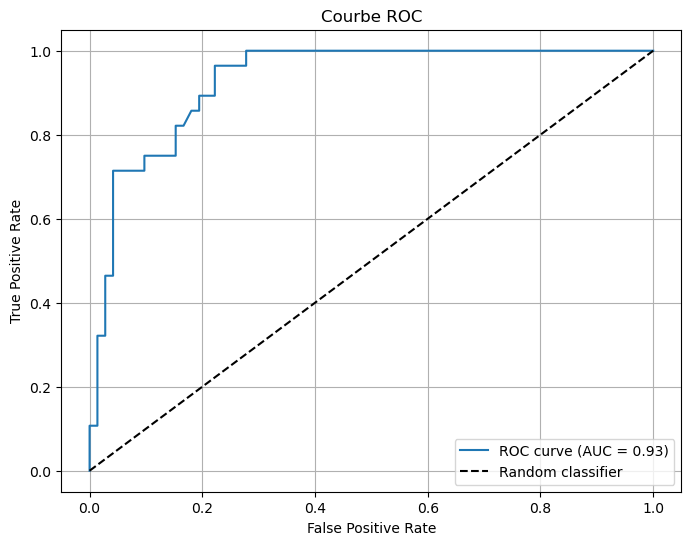

In [301]:
import matplotlib.pyplot as plt

y_score = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
auc_score = roc_auc_score(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()